# Load packages

In [1]:
import legoeducation as le
import time
import sys
import numpy as np
import matplotlib.pyplot as plt

# Connect to LEGO controllers

In [2]:
# update these values to match the Connection Card
card_color = le.LEGO_COLOR_AZURE
card_serial = '4261'

# Connect to the Single Motor
singlemotor = le.SingleMotor()
singlemotor.connect(card_color=card_color, card_serial=card_serial)
# Connect to the Double Motor
doublemotor = le.DoubleMotor()
doublemotor.connect(card_color=card_color, card_serial=card_serial)
# Connect to the Color Sensor
colorsensor = le.ColorSensor()
colorsensor.connect(card_color=card_color, card_serial=card_serial)

# Check connection
if not (singlemotor.connected and doublemotor.connected and colorsensor.connected):
	print('Error connecting to hardware.')
	sys.exit(1) # error connecting

# Define functions to find surface and scan

In [8]:
# Move single motor to find the z of surface at one point
def find_surface(degree_step, sensor_threshold, show_color_sensor_reading):
    singlemotor.motor_set_speed(speed=10)
    
    probe_direction_up = le.MOTOR_MOVE_DIRECTION_COUNTERCLOCKWISE
    probe_direction_down = le.MOTOR_MOVE_DIRECTION_CLOCKWISE
    # direction clockwise or +deg: down, counterclockwise or -deg: up
    
    sensor_initial_reflection = colorsensor.sensor.reflection
    sensor_detected = abs(sensor_initial_reflection-colorsensor.sensor.reflection) < sensor_threshold
    # Print detected color for five seconds
    while(sensor_detected):
        if show_color_sensor_reading:
            print(f"LEGO Color reflection: {colorsensor.sensor.reflection}")
        singlemotor.motor_run_for_degrees(degrees=degree_step)
        # print(f'Current z position: {singlemotor.motor.position}')
        sensor_detected = abs(sensor_initial_reflection - colorsensor.sensor.reflection) < sensor_threshold
        time.sleep(0.01)
        # singlemotor.motor_stop()
    
    final_z = singlemotor.motor.position
    final_z = -final_z # Minus sign makes z larger for higher in space
    return final_z

# move z back to initial position
def return_to_initial_z(initial_z,tolerance):
	singlemotor.motor_set_speed(speed=20)
	probe_relative_height = singlemotor.motor.position
	while(abs(probe_relative_height-initial_z)>tolerance):
		singlemotor.motor_run_to_relative_position(position=initial_z)
		# print(f'Current z position: {singlemotor.motor.position}')
		probe_relative_height = singlemotor.motor.position
		time.sleep(0.01)

# move x or y back to initial position
def return_to_initial_xy(initial_xy, xydirection, tolerance):
	doublemotor.motor_set_speed(speed=20)
	probe_relative_height = doublemotor.motor[xydirection].position
	while(abs(probe_relative_height-initial_xy)>tolerance):
		doublemotor.motor_run_to_relative_position(motor=xydirection,position=initial_xy)
		# print(f'Current xy position: {doublemotor.motor[xydirection].position}')
		probe_relative_height = doublemotor.motor[xydirection].position
		time.sleep(0.01)


# Example: Find the surface 

In [10]:
sensor_threshold = 2
z_degree_step = 3
initial_z = 0

singlemotor.motor_reset_relative_position()

surface_z = find_surface(z_degree_step, sensor_threshold, show_color_sensor_reading = 1)
return_to_initial_z(initial_z,3)
print(f'surface Z position: {surface_z}')

surface Z position: -106


# Example: Scan one line in X direction

Current pixel : 0
Current X position: 0
surface Z position: -89
Current pixel : 1
Current X position: 0
surface Z position: -91
Current pixel : 2
Current X position: -13
surface Z position: -91
Current pixel : 3
Current X position: -21
surface Z position: -94
Current pixel : 4
Current X position: -29
surface Z position: -91
Current pixel : 5
Current X position: -40
surface Z position: -92
Current pixel : 6
Current X position: -47
surface Z position: -59
Current pixel : 7
Current X position: -57
surface Z position: -57
Current pixel : 8
Current X position: -70
surface Z position: -59
Current pixel : 9
Current X position: -77
surface Z position: -62
Current pixel : 10
Current X position: -90
surface Z position: -57
Current pixel : 11
Current X position: -97
surface Z position: -94
Current pixel : 12
Current X position: -108
surface Z position: -91
Current pixel : 13
Current X position: -113
surface Z position: -91
Current pixel : 14
Current X position: -124
surface Z position: -91
Curren

Text(0.5, 1.0, 'X vs Z along one line')

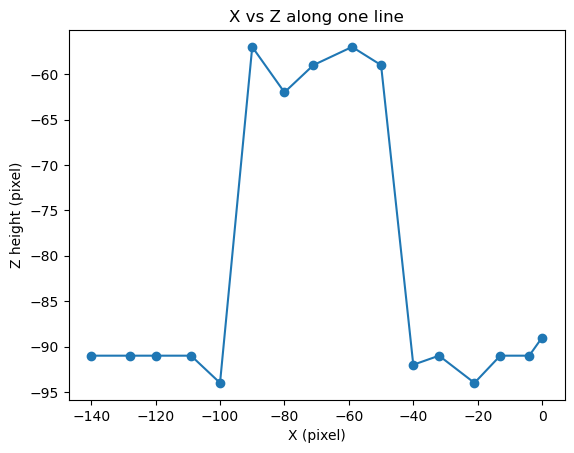

In [13]:
Npixel = 16 # Number of pixels in X

linex = np.zeros(Npixel)
linez = np.zeros(Npixel)

initial_xy = 0
xy_degree_step = 10

sensor_threshold = 2
z_degree_step = 3
initial_z = 0

singlemotor.motor_reset_relative_position()
doublemotor.motor_reset_relative_position()
doublemotor.motor_set_speed(speed=5)

xydirection = le.MOTOR_RIGHT
for i in range(Npixel):
    print(f'Current pixel : {i}')
    print(f'Current X position: {doublemotor.motor[le.MOTOR_RIGHT].position}')		
    surface_z = find_surface(z_degree_step, sensor_threshold, show_color_sensor_reading = 0)
    return_to_initial_z(initial_z,3)
    print(f'surface Z position: {surface_z}')
    linex[i]=doublemotor.motor[le.MOTOR_RIGHT].position
    linez[i]=surface_z		
    if i<Npixel-1:
        doublemotor.motor_run_for_degrees(motor=xydirection, direction=le.MOTOR_MOVE_DIRECTION_COUNTERCLOCKWISE, degrees=xy_degree_step)
    
return_to_initial_xy(initial_xy,xydirection,5)

plt.plot(linex, linez, marker='o', linestyle='-')
plt.xlabel("X (pixel)")
plt.ylabel("Z height (pixel)")
plt.title("X vs Z along one line")

# Example: Scan the surface

Current pixel : (0, 0)
Current X position: 0
Current Y position: 0
surface Z position: -104
Current pixel : (0, 1)
Current X position: -12
Current Y position: 0
surface Z position: -100
Current pixel : (0, 2)
Current X position: -31
Current Y position: 0
surface Z position: -101
Current pixel : (0, 3)
Current X position: -53
Current Y position: 0
surface Z position: -67
Current pixel : (0, 4)
Current X position: -74
Current Y position: 0
surface Z position: -102
Current pixel : (0, 5)
Current X position: -90
Current Y position: 0
surface Z position: -100
Current pixel : (0, 6)
Current X position: -111
Current Y position: 0
surface Z position: -104
Current pixel : (0, 7)
Current X position: -130
Current Y position: 0
surface Z position: -101
Current pixel : (1, 0)
Current X position: 0
Current Y position: -2
surface Z position: -103
Current pixel : (1, 1)
Current X position: -13
Current Y position: 0
surface Z position: -101
Current pixel : (1, 2)
Current X position: -32
Current Y posit

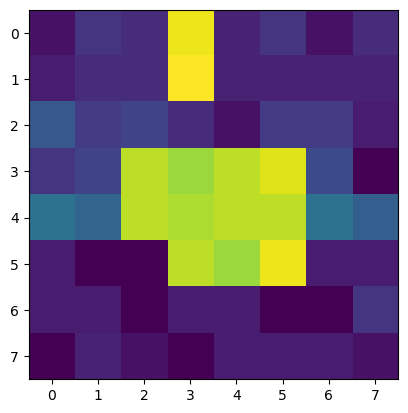

In [16]:
Npixel = 8 # Number of pixels in X and Y

topographx = np.zeros((Npixel,Npixel))
topography = np.zeros((Npixel,Npixel))
topographz = np.zeros((Npixel,Npixel))

initial_xy = 0
xy_degree_step = 20

sensor_threshold = 2
z_degree_step = 3
initial_z = 0

singlemotor.motor_reset_relative_position()
doublemotor.motor_reset_relative_position()
doublemotor.motor_set_speed(speed=5)

# xydirection=le.MOTOR_RIGHT # MOTOR_RIGHT: x, MOTOR_LEFT: y

for i in range(Npixel):
	xydirection = le.MOTOR_RIGHT
	for j in range(Npixel):
		print(f'Current pixel : {i,j}')
		print(f'Current X position: {doublemotor.motor[le.MOTOR_RIGHT].position}')
		print(f'Current Y position: {doublemotor.motor[le.MOTOR_LEFT].position}')
		surface_z = find_surface(z_degree_step, sensor_threshold, show_color_sensor_reading = 0)
		return_to_initial_z(initial_z,3)
		print(f'surface Z position: {surface_z}')
		topographx[i,j]=doublemotor.motor[le.MOTOR_RIGHT].position
		topography[i,j]=doublemotor.motor[le.MOTOR_LEFT].position
		topographz[i,j]=surface_z
		if j<Npixel-1:
			doublemotor.motor_run_for_degrees(motor=xydirection, direction=le.MOTOR_MOVE_DIRECTION_COUNTERCLOCKWISE, degrees=xy_degree_step)
		# time.sleep(0.1)
	return_to_initial_xy(initial_xy,xydirection,5)
	xydirection = le.MOTOR_LEFT
	if i<Npixel-1:
		doublemotor.motor_run_for_degrees(motor=xydirection, degrees=-xy_degree_step)

return_to_initial_xy(initial_xy,xydirection,5)

plt.imshow(topographz)
plt.show()

# Disconnect LEGO controllers

In [17]:
# Disconnect
singlemotor.disconnect()
doublemotor.disconnect()
colorsensor.disconnect()